# MiloDE on in vitro HE multiome

In [1]:
library(miloDE)

# analysis libraries
library(scuttle)
suppressMessages(library(miloR))
suppressMessages(library(uwot))
library(scran)
suppressMessages(library(dplyr))
library(reshape2)

# packages for gene cluster analysis
library(scWGCNA)
#> 
suppressMessages(library(Seurat))

# plotting libraries
library(ggplot2)
library(viridis)
#> Loading required package: viridisLite
library(ggpubr)

library(BiocParallel)
ncores = 16
mcparam = MulticoreParam(workers = ncores)
register(mcparam)

Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    

In [5]:
here::i_am("rna_atac/dimensionality_reduction/WNN_MOFA.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



In [11]:
args = list()
# MOFAsprintf('%s/results/rna_atac/combined_metadata.txt.gz',io$basedir)
args$metadata = file.path(io$basedir, 'results/rna_atac/combined_metadata.txt.gz')
args$MOFA = file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/mofa/MOFA_factors.txt.gz')
args$MOFA_umap = file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/mofa/MOFA_umap.txt.gz')

# RNA_sce
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')


# outdir
args$outdir_clusters = file.path(io$basedir, 'results/rna/milo/')
dir.create(args$outdir_clusters, recursive=TRUE, showWarnings =FALSE)

In [81]:
io$basedir

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood"

In [13]:
seurat = readRDS(sprintf('%s/results/rna_atac/dimensionality_reduction/seurat_object.rds', io$basedir))
umap = fread(args$MOFA_umap)
meta = fread(args$metadata)

In [16]:
EmbryoCelltypeColours = c(
  "Epiblast",
  "Primitive_Streak",
  "Caudal_epiblast",
  "PGC",
  "Anterior_Primitive_Streak",
  "Notochord",
  "Def._endoderm",
  "Gut",
  "Nascent_mesoderm",
  "Mixed_mesoderm",
  "Intermediate_mesoderm",
  "Caudal_Mesoderm",
  "Paraxial_mesoderm",
  "Somitic_mesoderm",
  "Pharyngeal_mesoderm",
  "Cardiomyocytes",
  "Allantois",
  "ExE_mesoderm",
  "Mesenchyme",
  "Haematoendothelial_progenitors",
  "Endothelium",
  "Blood_progenitors_1",
  "Blood_progenitors_2",
  "Erythroid1",
  "Erythroid2",
  "Erythroid3",
  "NMP",
  "Rostral_neurectoderm",
  "Caudal_neurectoderm",
  "Neural_crest",
  "Forebrain_Midbrain_Hindbrain",
  "Spinal_cord",
  "Surface_ectoderm",
  "Visceral_endoderm",
  "ExE_endoderm",
  "ExE_ectoderm",
  "Parietal_endoderm"
)


In [17]:
seurat

An object of class Seurat 
32285 features across 33177 samples within 1 assay 
Active assay: RNA (32285 features, 0 variable features)
 2 dimensional reductions calculated: mofa, umap

In [19]:
# load chimera Tal1
sce = as.SingleCellExperiment(seurat)

In [23]:
# for this exercise, we focus on 3000 highly variable genes (for computational efficiency)
dec.sce = modelGeneVar(sce)
hvg.genes = getTopHVGs(dec.sce, n = 3000)
sce = sce[hvg.genes , ]


In [ ]:

# add UMAPs
set.seed(32)
umaps = umap %>% as.data.frame() %>% tibble::column_to_rownames('cell')
# let's store UMAPs - we will use them for visualisation
reducedDim(sce , "UMAP") = umaps

In [28]:
palette = c('1'='#D51F26',
            '2'='#272E6A',
            '3'='#208A42',
            '4'='#89288F',
            '5'='#F47D2B',
            '6'='#FEE500',
            '7'='#8A9FD1',
            '8'='#C06CAB',
            '9'='#E6C2DC',
            '10'='#90D5E4',
            '11'='#89C75F',
            '12'='#F37B7D',
            '13'='#9983BD',
            '14'='#D24B27',
            '15'='#3BBCA8',
            '16'='#6E4B9E',
            '17'='#0C727C',
            '18'='#7E1416',
            '19'='#D8A767',
            '20'='#3D3D3D',
            '21'='#D51F26')

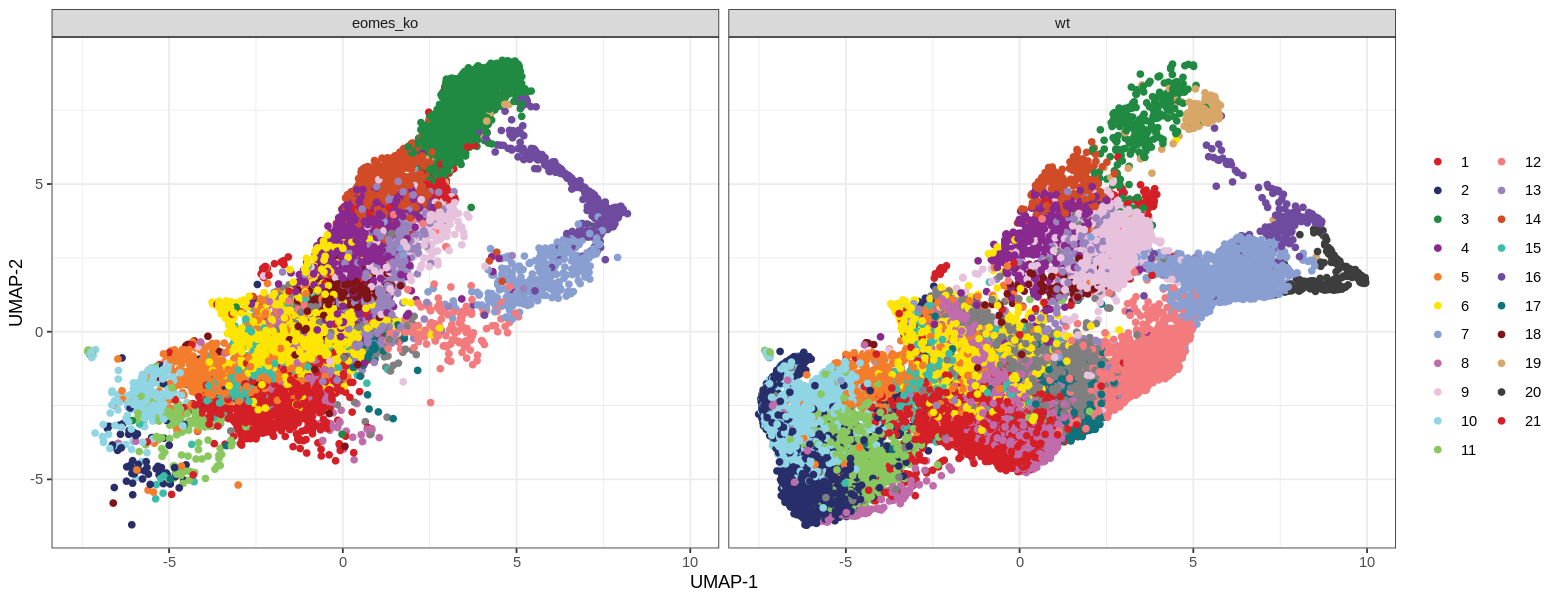

In [32]:
options(repr.plot.height=5, repr.plot.width=13)
# plot UMAPs, colored by cell types
umaps = cbind(as.data.frame(colData(sce)) , reducedDim(sce , "UMAP"))

p = ggplot(umaps , aes(x = UMAP1 , y = UMAP2 , col = seurat_clusters)) +
  geom_point() + 
  scale_color_manual(values=palette, name='') +
  facet_wrap(~genotype) +
  theme_bw() + 
  labs(x = "UMAP-1", y = "UMAP-2")
p

In [33]:
# Remove D3 cells as they are just WT starting point
sce = sce[,colData(sce)$day != 'D3']

Running for next k values:
15, 17, 19



100% covered by 219 sets.


Finished for k = 15



100% covered by 180 sets.


Finished for k = 17



100% covered by 157 sets.


Finished for k = 19

Finished the estimation of neighbourhood sizes ~ k dependancy (order = 2).





Table: Neighbourhood size distribution ~ k

|k  | min|    q25| med|   q75|  max|
|:--|---:|------:|---:|-----:|----:|
|15 |  70| 306.00| 428| 599.5| 1591|
|17 | 103| 352.25| 528| 730.5| 1866|
|19 |  90| 434.00| 610| 829.0| 2136|

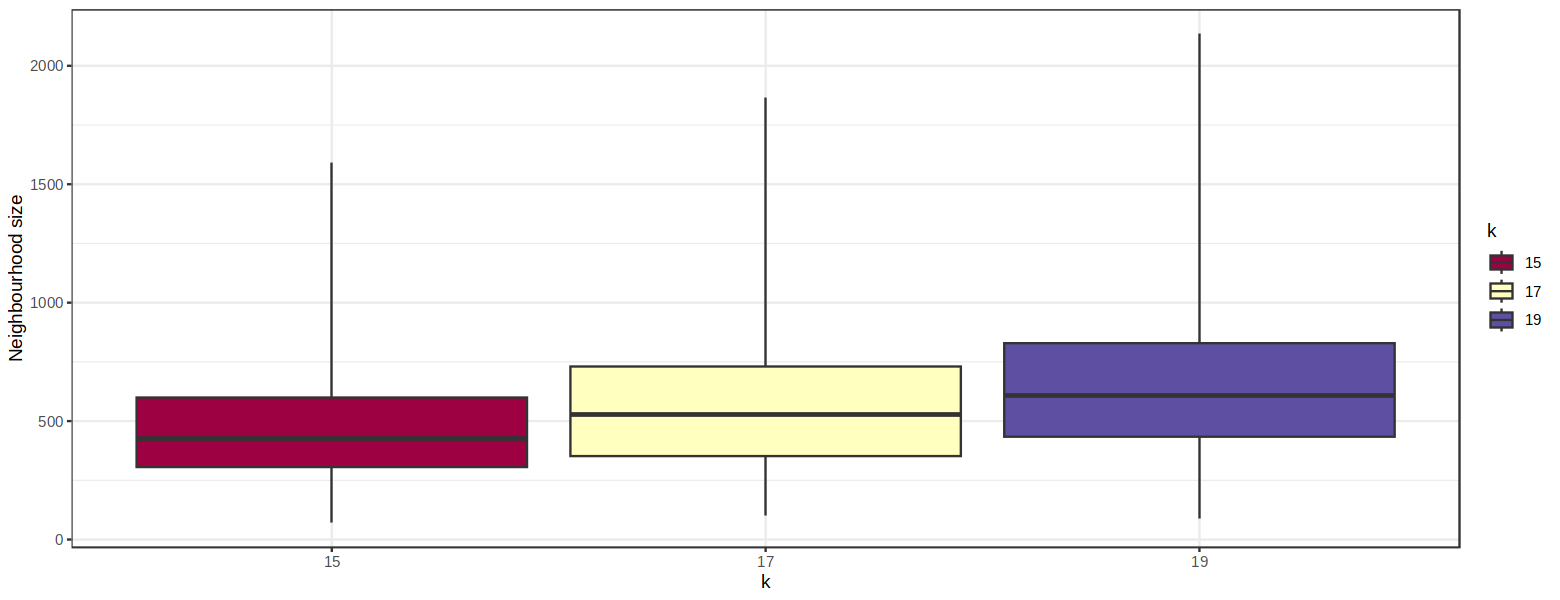

In [87]:
stat_k = estimate_neighbourhood_sizes(sce, k_grid = seq(15,20,2) , 
                                      order = 2, prop = 0.3 , filtering = TRUE,
                                      reducedDim_name = "MOFA" , plot_stat = TRUE)
knitr::kable(stat_k , caption = "Neighbourhood size distribution ~ k")

In [88]:
set.seed(32)
# What does order mean here?
sce_milo = assign_neighbourhoods(sce , k = 25, prop = 0.3 , order = 2, 
                                 filtering = TRUE , reducedDim_name = "MOFA" , verbose = F)

100% covered by 114 sets.


Warning message in plot_milo_by_single_metric(sce_milo, nhood_stat_ct, colour_by = "seurat_clusters", :
“Coercing layout to matrix format”
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


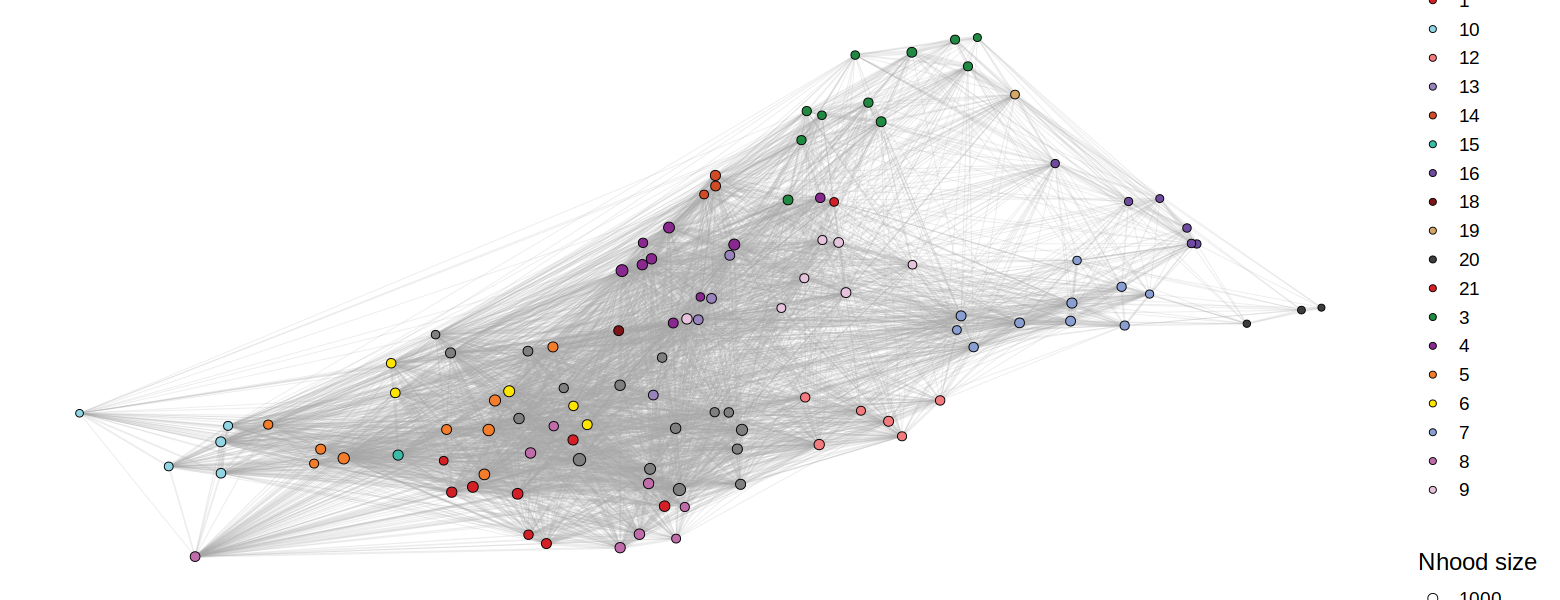

In [89]:
nhoods_sce = nhoods(sce_milo)
# assign cell types for nhoods 
nhood_stat_ct = data.frame(Nhood = 1:ncol(nhoods_sce) , Nhood_center = colnames(nhoods_sce))
nhood_stat_ct = miloR::annotateNhoods(sce_milo , nhood_stat_ct , coldata_col = "seurat_clusters")
#> Converting seurat_clusters to factor...
p = plot_milo_by_single_metric(sce_milo, nhood_stat_ct, colour_by = "seurat_clusters" , 
                                      layout = "UMAP" , size_range = c(1.5,3) , edge_width = c(0.2,0.5)) + 
  scale_fill_manual(values = palette , name = "Cluster")
p

In [90]:
stat_auc = suppressWarnings(calc_AUC_per_neighbourhood(sce_milo , sample_id = "sample" , condition_id = "genotype", min_n_cells_per_sample = 1, BPPARAM = mcparam))

p = plot_milo_by_single_metric(sce_milo, stat_auc, colour_by = "auc" , 
                                      layout = "UMAP" , size_range = c(1.5,3) , edge_width = c(0.2,0.5)) + 
  scale_fill_viridis(name = "AUC")

Warning message in plot_milo_by_single_metric(sce_milo, stat_auc, colour_by = "auc", :
“Coercing layout to matrix format”
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


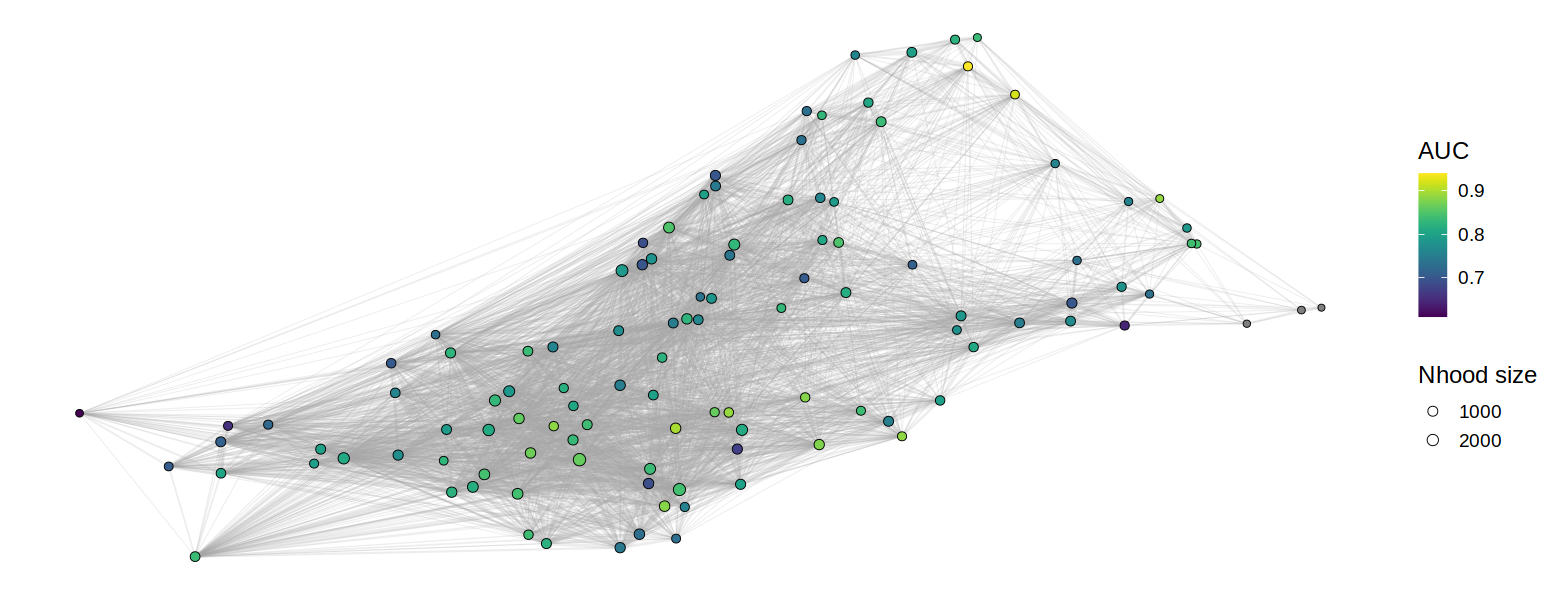

In [91]:
p

Starting DE testing within each neighbourhood:

R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno

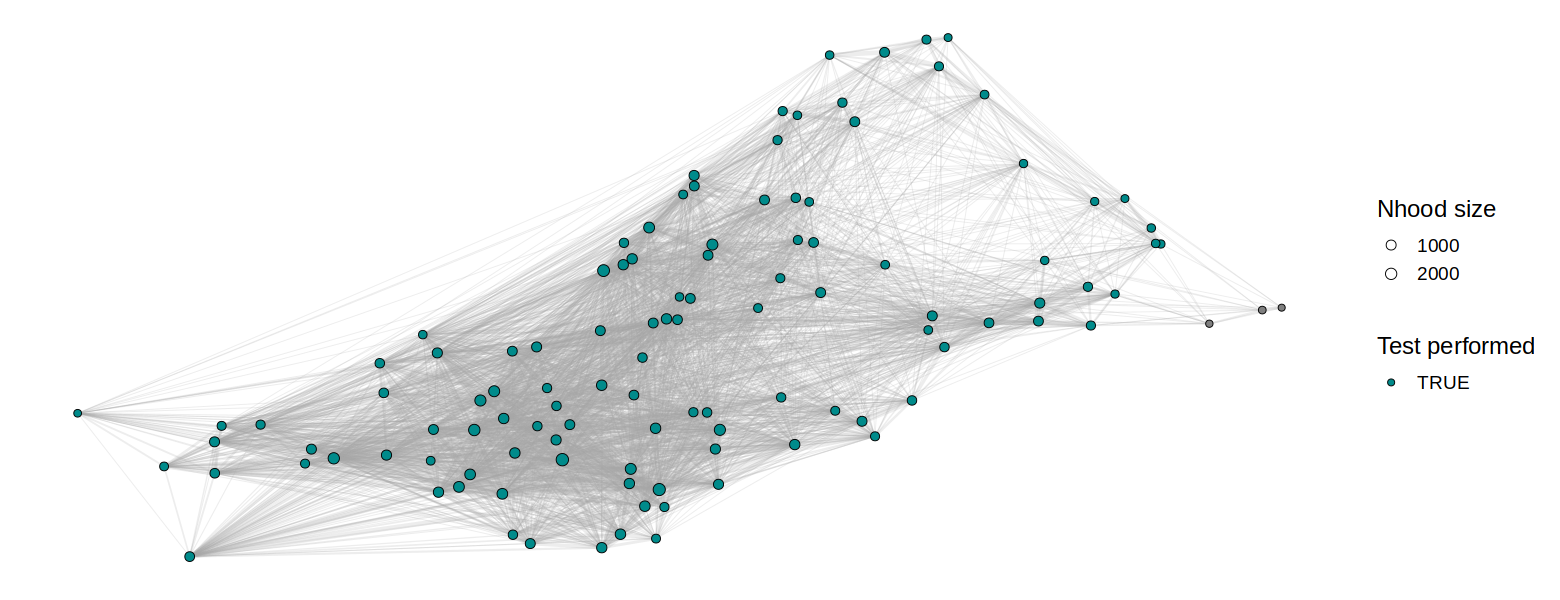

In [92]:
de_stat = de_test_neighbourhoods(sce_milo ,
                             sample_id = "sample",
                             design = ~genotype,
                             covariates = c("genotype"), # why covariate same as design?
                             subset_nhoods = stat_auc$Nhood[!is.na(stat_auc$auc)],
                             output_type = "SCE",
                             plot_summary_stat = TRUE,
                             layout = "UMAP", BPPARAM = mcparam , 
                             verbose = T)

Warning message in plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by = "n_DE_genes", :
“Coercing layout to matrix format”
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Warning message in plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by = "n_specific_DE_genes", :
“Coercing layout to matrix format”
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


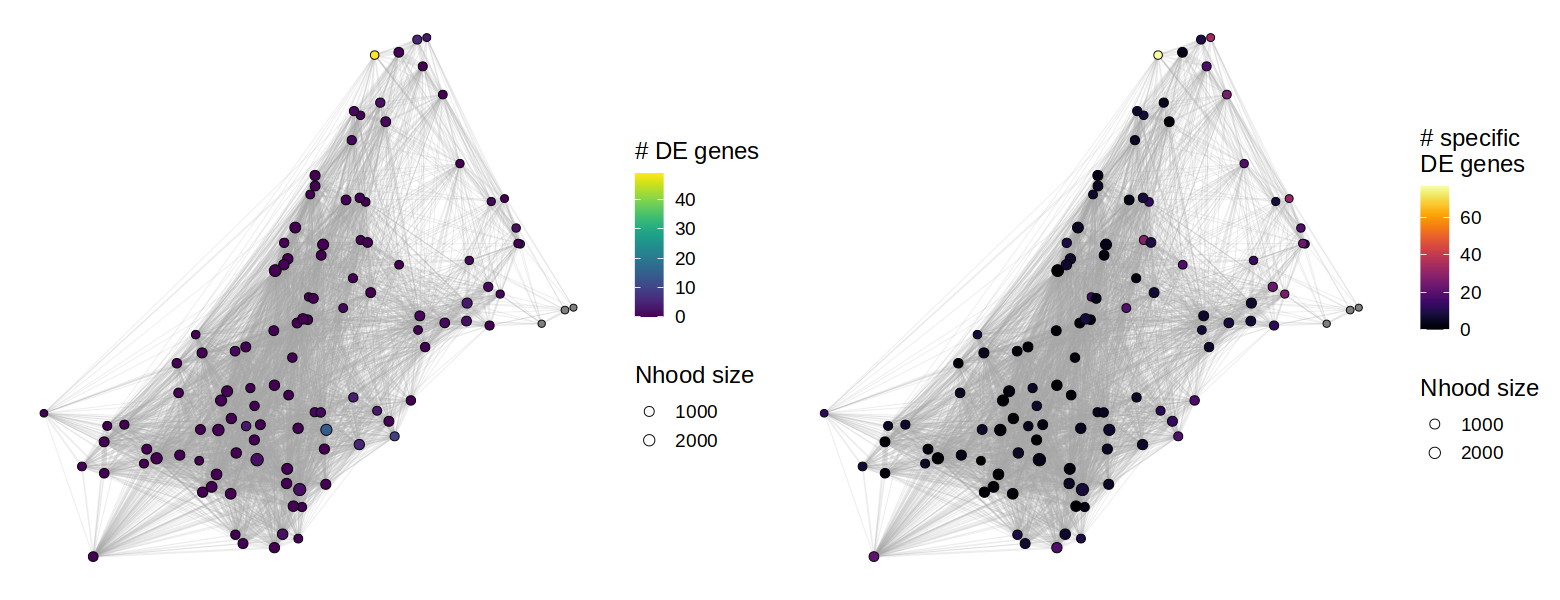

In [93]:
stat_de_magnitude = rank_neighbourhoods_by_DE_magnitude(de_stat)

p1 = plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by = "n_DE_genes" , 
                                      layout = "UMAP" , size_range = c(1.5,3) , edge_width = c(0.2,0.5)) + 
  scale_fill_viridis(name = "# DE genes")
#> Warning in plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by =
#> "n_DE_genes", : Coercing layout to matrix format
#> Scale for 'fill' is already present. Adding another scale for 'fill', which
#> will replace the existing scale.
p2 = plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by = "n_specific_DE_genes" , 
                                      layout = "UMAP" , size_range = c(1.5,3) , edge_width = c(0.2,0.5)) + 
  scale_fill_viridis(name = "# specific\nDE genes" , option = "inferno")
#> Warning in plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by =
#> "n_specific_DE_genes", : Coercing layout to matrix format
#> Scale for 'fill' is already present. Adding another scale for 'fill', which
#> will replace the existing scale.
p = ggarrange(p1,p2)
p

Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”


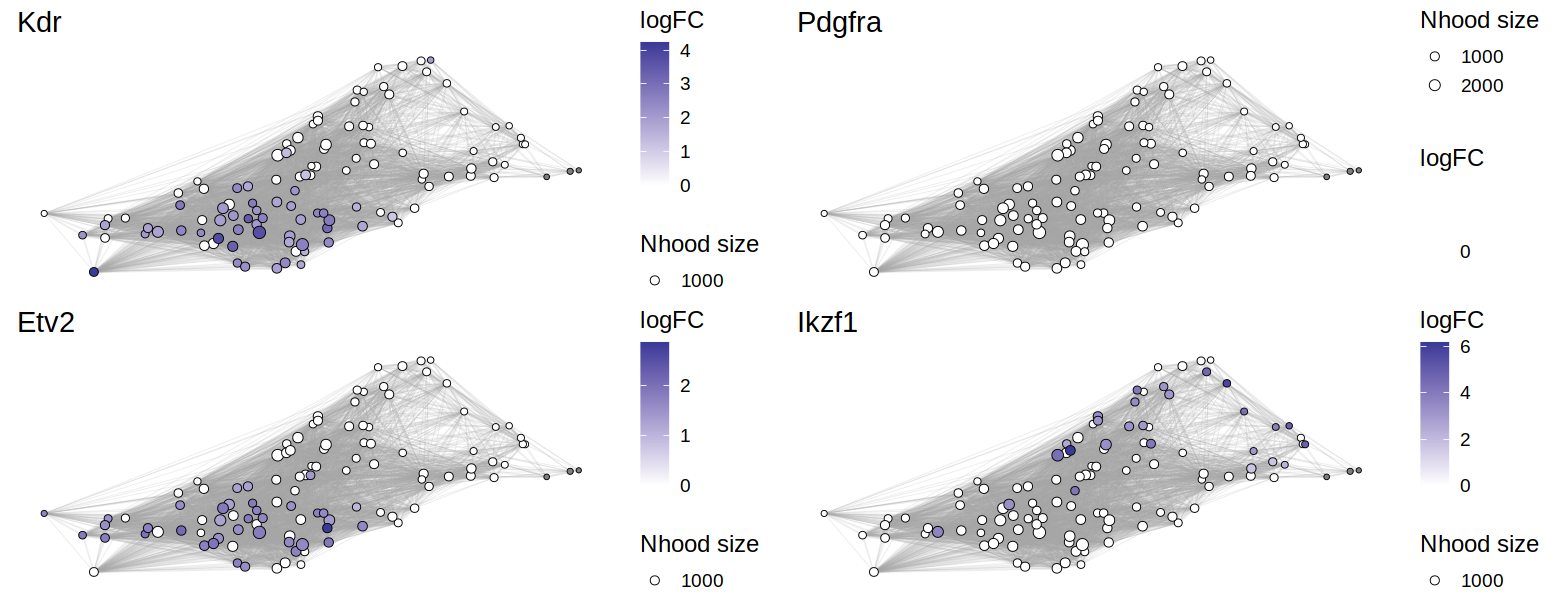

In [94]:
genes = c('Kdr','Pdgfra', 'Etv2', 'Ikzf1')
plots = lapply(genes , function(gene){
  p = plot_DE_single_gene(sce_milo, de_stat , gene = gene , layout = "UMAP" , set_na_to_0 = TRUE) + 
    ggtitle(gene)
  return(p)
})

p = ggarrange(plotlist = plots, ncol=2, nrow=2)
p

Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”


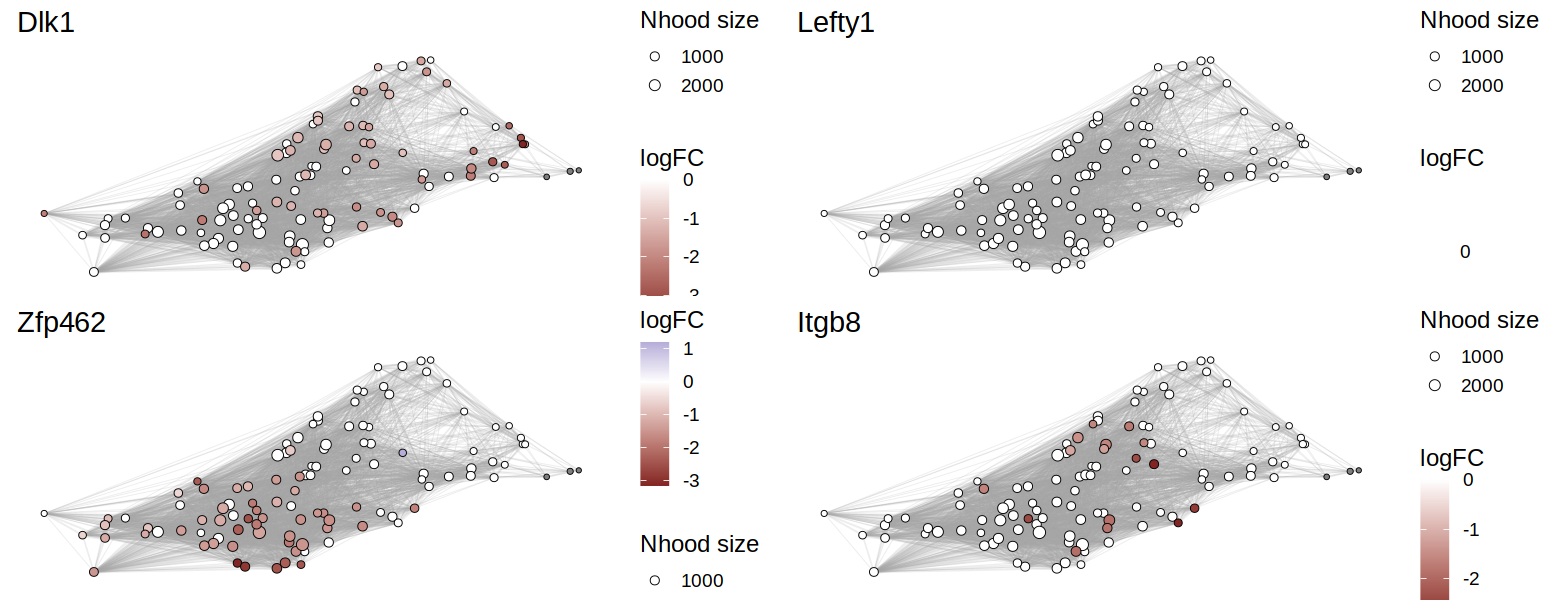

In [95]:
genes = c('Dlk1','Lefty1', 'Zfp462', 'Itgb8')
plots = lapply(genes , function(gene){
  p = plot_DE_single_gene(sce_milo, de_stat , gene = gene , layout = "UMAP" , set_na_to_0 = TRUE) + 
    ggtitle(gene)
  return(p)
})

p = ggarrange(plotlist = plots, ncol=2, nrow=2)
p

In [96]:
get_wgcna_modules = function(de_stat , subset_hoods = NULL , 
                             n_hoods_sig.thresh = 2 ,
                             npcs = 5 ,
                             pval.thresh = 0.1 ){
  require(scWGCNA)
  require(Seurat)
  require(dplyr)
  require(reshape2)
  
  set.seed(32)
  # subset hoods
  if (!is.null(subset_hoods)){
    de_stat = de_stat[de_stat$Nhood %in% subset_hoods , ]
  }
  
  # focus on genes that DE in at least 2 nhoods
  de_stat_per_gene = as.data.frame(de_stat %>% group_by(gene) %>% dplyr::summarise(n_hoods_sig = sum(pval_corrected_across_nhoods < pval.thresh , na.rm = TRUE)))
  genes_sig = de_stat_per_gene$gene[de_stat_per_gene$n_hoods_sig >= n_hoods_sig.thresh]
  
  de_stat = de_stat[de_stat$gene %in% genes_sig, ]
  de_stat = de_stat[order(de_stat$Nhood) , ]
  
  # discard neighbourhoods in which testing was not performed
  de_stat = de_stat[de_stat$test_performed , ]
  
  # for this analysis, set logFC to 0 and pvals to 1 if they are NaN
  de_stat$logFC[is.na(de_stat$logFC)] = 0
  de_stat$pval[is.na(de_stat$pval)] = 1
  de_stat$pval_corrected_across_genes[is.na(de_stat$pval_corrected_across_genes)] = 1
  de_stat$pval_corrected_across_nhoods[is.na(de_stat$pval_corrected_across_nhoods)] = 1
  
  # set logFC to 0 if pval_corrected_across_nhoods > pval.thresh
  de_stat$logFC[de_stat$pval_corrected_across_nhoods >= pval.thresh] = 0
  
  # move the object to Seurat
  de_stat = reshape2::dcast(data = de_stat, formula = gene~Nhood, value.var = "logFC")
  rownames(de_stat) = de_stat$gene
  de_stat = de_stat[,2:ncol(de_stat)]
  
  obj.seurat <- CreateSeuratObject(counts = de_stat)
  DefaultAssay(obj.seurat) <- "RNA"
  obj.seurat = FindVariableFeatures(obj.seurat)
  # scale
  obj.seurat[["RNA"]]@scale.data = as.matrix(obj.seurat[["RNA"]]@data)
  obj.seurat = RunPCA(obj.seurat , npcs = npcs)
  
  # run scwgcna
  clusters_scwgcna = run.scWGCNA(p.cells = obj.seurat, 
                                 s.cells = obj.seurat, 
                                 is.pseudocell = F, 
                                 features = rownames(obj.seurat),
                                 less = TRUE , merging = TRUE)
  # compile stat
  clusters = lapply(1:length(clusters_scwgcna$module.genes) , function(i){
    out = data.frame(cluster = i , gene = clusters_scwgcna$module.genes[[i]] , n_genes = length(clusters_scwgcna$module.genes[[i]]))
    return(out)
  })
  clusters = do.call(rbind , clusters)
  # add colors
  genes_w_colors = clusters_scwgcna$dynamicCols
  genes_w_colors = data.frame(gene = names(genes_w_colors) , cluster_color = genes_w_colors)
  clusters = merge(clusters , genes_w_colors)
  
  return(clusters)
}


In [97]:
as.data.table(convert_de_stat(de_stat))[logFC<=-1 & pval_corrected_across_nhoods < 0.05]

Converting de_stat to 'data.frame' format



Nhood,gene,logFC,pval,pval_corrected_across_genes,pval_corrected_across_nhoods,Nhood_center,test_performed
<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
1,Zfp462,-1.535391,7.057238e-04,0.98095605,0.008533590,14724,TRUE
2,Zfp462,-1.164024,3.820684e-03,0.99449008,0.025660052,8313,TRUE
3,Zfp462,-1.480146,6.238859e-04,0.28526912,0.008093841,459,TRUE
4,Dlk1,-1.175831,1.377801e-02,0.99960209,0.037430256,15053,TRUE
5,Limch1,-1.246000,3.603800e-03,0.54972141,0.019176681,22253,TRUE
6,Dlk1,-1.306823,1.075572e-02,0.92671963,0.033307168,12262,TRUE
7,Zfp462,-1.384045,1.523656e-03,0.99177308,0.014406631,14596,TRUE
8,Limch1,-1.271459,6.374598e-03,0.31481332,0.029444093,4339,TRUE
10,Dlk1,-2.946059,1.097465e-02,0.64650200,0.033307168,24995,TRUE


Warning message in eval(predvars, data, env):
“NaNs produced”
Warning message in hvf.info$variance.expected[not.const] <- 10^fit$fitted:
“number of items to replace is not a multiple of replacement length”


[1] "We have 61 genes in the variable genes object"


Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'x'. Pearson correlation was used for individual columns with zero (or missing) MAD.”
Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'y'. Pearson correlation was used for individual columns with zero (or missing) MAD.”


   Power SFT.R.sq  slope truncated.R.sq  mean.k. median.k. max.k.
1      1   0.1880 -56.30        0.01280 30.50000  3.05e+01 33.100
2      2   0.2240 -31.60        0.04650 16.00000  1.59e+01 18.900
3      3   0.2110 -19.00        0.04010  8.63000  8.51e+00 11.200
4      4   0.3790  -2.79        0.73600  4.79000  4.66e+00  6.830
5      5   0.4610  -1.69        0.75300  2.74000  2.68e+00  4.290
6      6   0.5240  -1.90        0.53100  1.62000  1.59e+00  2.960
7      7   0.7240  -2.07        0.68000  0.99400  9.24e-01  2.240
8      8   0.1870  -4.54       -0.04410  0.63100  5.46e-01  1.770
9      9   0.2210  -5.59        0.00538  0.41500  3.37e-01  1.450
10    10   0.2430  -5.87        0.07710  0.28300  2.02e-01  1.210
11    12   0.2500  -4.95        0.05930  0.14600  8.30e-02  0.911
12    14   0.2580  -4.91        0.12800  0.08520  3.47e-02  0.728
13    16   0.1890  -4.00        0.10800  0.05500  1.52e-02  0.598
14    18   0.2730  -4.11        0.07170  0.03830  7.06e-03  0.499
15    20  

Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'x'. Pearson correlation was used for individual columns with zero (or missing) MAD.”


...

Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'x'. Pearson correlation was used for individual columns with zero (or missing) MAD.”


TOM calculation: adjacency..
..will not use multithreading.
 Fraction of slow calculations: 0.000000
..connectivity..
..matrix multiplication (system BLAS)..
..normalization..
..done.
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module d

Warning message in min(x, na.rm = T):
“no non-missing arguments to min; returning Inf”
Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'x'. Pearson correlation was used for individual columns with zero (or missing) MAD.”


TOM calculation: adjacency..
..will not use multithreading.
 Fraction of slow calculations: 0.000000
..connectivity..
..matrix multiplication (system BLAS)..
..normalization..
..done.


ERROR: Error in data.frame(i, j, dim(z), names(z[1]), unname(z[1])): arguments imply differing number of rows: 1, 0


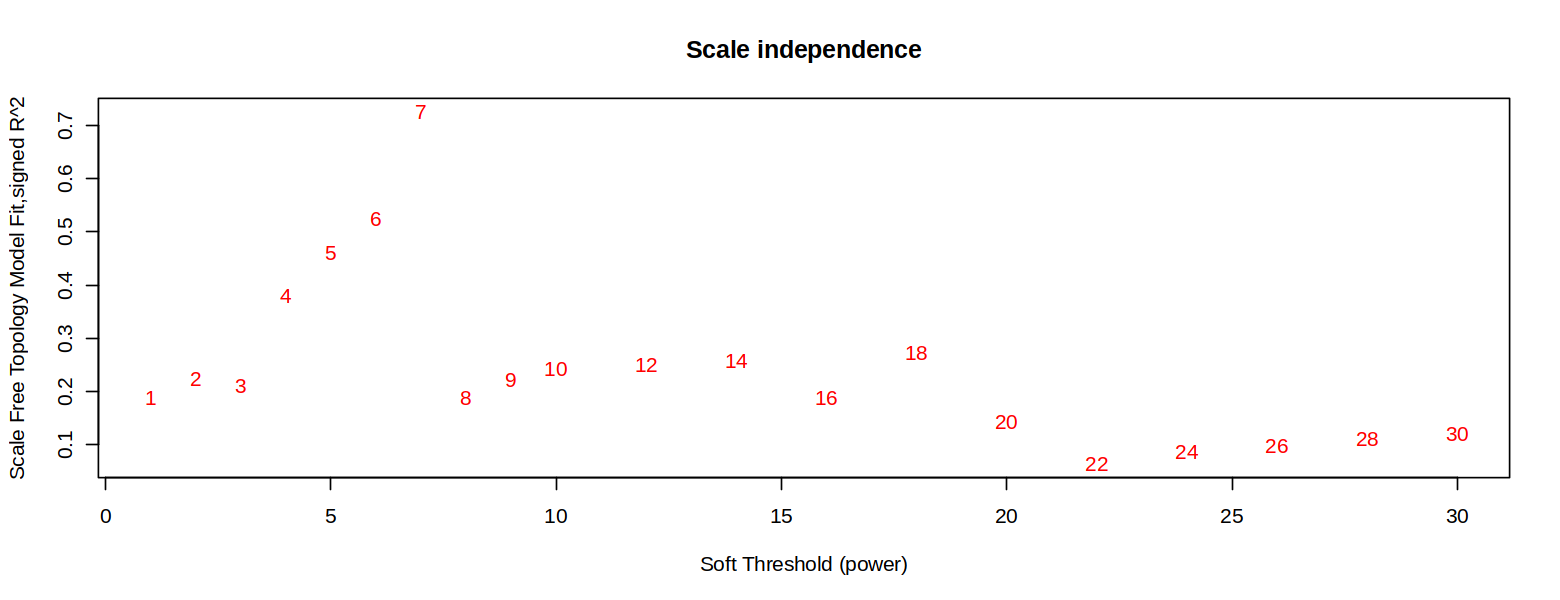

In [98]:


# for this vignette, for simplicity we will focus on genes that are DE in at least 4 neighbourhoods
modules_wgcna = suppressMessages(get_wgcna_modules(convert_de_stat(de_stat) , n_hoods_sig.thresh = 4))

In [ ]:
plots = lapply(sort(unique(modules_wgcna$cluster)) , function(cluster){
  p = plot_DE_gene_set(sce_milo, de_stat , genes = modules_wgcna$gene[modules_wgcna$cluster == cluster],
                            layout = "UMAP" , size_range = c(0.5,3) ,
                            node_stroke = 0.3, edge_width = c(0.2,0.5)) +
    ggtitle(paste0("Module ", cluster, ", ", length(modules_wgcna$gene[modules_wgcna$cluster == cluster]) , " genes"))
  return(p)
})

In [ ]:
options(repr.plot.height=8, repr.plot.width=13)
p = ggarrange(plotlist = plots)
p

In [ ]:
# we first need to assign cell type label to each neighbourhood - we have calculated it previously
# we will use data.frame format for de-stat; the conversion between SingleCellExperiment and data.frame formats can be done using `convert_de_stat`
de_stat_df = convert_de_stat(de_stat)
#> Converting de_stat to 'data.frame' format
de_stat_df = merge(de_stat_df , nhood_stat_ct , by = c("Nhood" , "Nhood_center"))


plots = lapply(sort(unique(modules_wgcna$cluster)) , function(cluster){
  p = plot_beeswarm_gene_set(de_stat_df, 
                             genes = modules_wgcna$gene[modules_wgcna$cluster == cluster], 
                             nhoodGroup = "celltype.mapped") + 
    ggtitle(paste0("Module ", cluster))
  return(p)
})
#> Converting de_stat to 'SingleCellExperiment' format
#> Converting de_stat to 'SingleCellExperiment' format
#> Converting de_stat to 'SingleCellExperiment' format
#> Converting de_stat to 'SingleCellExperiment' format
p = ggarrange(plotlist = plots)
p

In [ ]:
set.seed(1020)
module = 2
n_genes = 6
genes = sample(modules_wgcna$gene[modules_wgcna$cluster == module] , n_genes)


plots = lapply(genes , function(gene){
  p = plot_DE_single_gene(sce_milo, de_stat , gene = gene , layout = "UMAP" , set_na_to_0 = TRUE) + 
    ggtitle(gene)
  return(p)
})
#> Converting de_stat to 'data.frame' format
#> Warning in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by =
#> "logFC", : Coercing layout to matrix format
#> Converting de_stat to 'data.frame' format
#> Warning in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by =
#> "logFC", : Coercing layout to matrix format
#> Converting de_stat to 'data.frame' format
#> Warning in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by =
#> "logFC", : Coercing layout to matrix format
#> Converting de_stat to 'data.frame' format
#> Warning in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by =
#> "logFC", : Coercing layout to matrix format
#> Converting de_stat to 'data.frame' format
#> Warning in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by =
#> "logFC", : Coercing layout to matrix format
#> Converting de_stat to 'data.frame' format
#> Warning in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by =
#> "logFC", : Coercing layout to matrix format
p = ggarrange(plotlist = plots , ncol = 2, nrow = 3)
p

In [ ]:

set.seed(1020)
module = 4
n_genes = 6
genes = sample(modules_wgcna$gene[modules_wgcna$cluster == module] , n_genes)


plots = lapply(genes , function(gene){
  p = plot_DE_single_gene(sce_milo, de_stat , gene = gene , layout = "UMAP" , set_na_to_0 = TRUE) + 
    ggtitle(gene)
  return(p)
})
#> Converting de_stat to 'data.frame' format
#> Warning in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by =
#> "logFC", : Coercing layout to matrix format
#> Converting de_stat to 'data.frame' format
#> Warning in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by =
#> "logFC", : Coercing layout to matrix format
#> Converting de_stat to 'data.frame' format
#> Warning in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by =
#> "logFC", : Coercing layout to matrix format
#> Converting de_stat to 'data.frame' format
#> Warning in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by =
#> "logFC", : Coercing layout to matrix format
#> Converting de_stat to 'data.frame' format
#> Warning in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by =
#> "logFC", : Coercing layout to matrix format
#> Converting de_stat to 'data.frame' format
#> Warning in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by =
#> "logFC", : Coercing layout to matrix format
p = ggarrange(plotlist = plots, ncol=2, nrow=3)
p